EDA on Titanic data

We will do EDA on Titanic data from Kaggle. 

We will see to understand what features has impacted survival

# https://www.kaggle.com/c/titanic/data

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
train_file = '/Users/raj/Documents/Corpnce AI/practice/EDA/titanic/train.csv'
test_file = '/Users/raj/Documents/Corpnce AI/practice/EDA/titanic/test.csv'

In [23]:
df = pd.read_csv(train_file)
print(df.shape) # (891 rows and 12 columns)
print(df.info())
print(df.describe())
print(df.isnull().sum().sort_values(ascending=False))
print(df.duplicated().sum())

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

# Observations from above cell
```python

1. 891 rows, 12 columns:
    a. Small data set
    b. manageable number of features

2. features object types:
    a. PassengerID: Unique, int64, nominal (Special case of being indexing), qualitative (Primary Key, Identifier Variable)
    b. Survived: int64, binary, nominal, categorical, qualitative
    c. Pclass: int64, categorical, multi-class, ordinal, qualitative
    d. Name: string, nominal, qualitative, High cardinality categorical
    e. Sex: string, categorical, nominal, qualitative
    f. Age: float64, continous, numerical, quantitative. --> data is missing
    g. Sibsp (Sibilings/Spouse aboard): int64, Discrete, numerical, quantitative
    h. Parch (Parent/Children aboard): int64, Discrete, numerical, quantitative
    i. Ticket: string, Alpha numeric, nominal, categorical
    j. Fare: float64, numerical, continous, quantitative
    k. Cabin: string, categorical, multi-class, qualitative --> data is missing
    l. Embarked: string, multi-class, qualitative, categorical. --> data is missing


3. df.describe()
    a. PassengerID: NO missing data, gaussian
    b. Survivied: NO missing data, left skewed, widely spread
    c. Pclass: NO missing data, right skewed, 
    d. Age: missing data, left skewed, outliers on right
    e. Sibsp: NO missing data, left skewed, widely spread, outliers on right
    f. Parch: NO missing data, left skewed, widely spread, outliers on right
   g. Fare: NO missing data, right skewed, widely spread, outliers on right

```

```python
4. How to handle missing data
    Age: 
        a. We cannot drop the missing Age.
        b. Adding mean will reduce variance, it includes skew values which can increase skew.
        c. Adding median would be better. we are adding right data, but data to fill the gaps.
    Cabin:
        a. Categorical, can't add median
        b. May be better to drop, too many missing, High Carinality (too many types)
        c. In a Ship Decks can be few (4 or 5 unlike cabins), can extract decks and have 'unknown' as one category.
    Embarked:
        a. Filling with Mode, as there are very few missing and distribution won't be distrubed.
```

Visualization

In [24]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Survival distribution

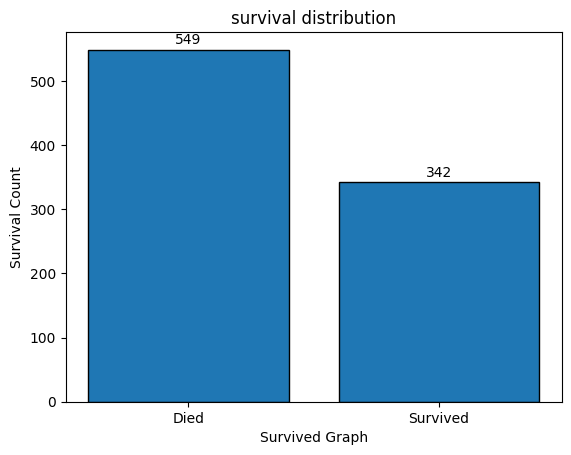

In [81]:
survival_counts = df['Survived'].value_counts()

ax = plt.bar(survival_counts.index, survival_counts.values, edgecolor='black')
plt.xticks([0, 1], ['Died', 'Survived'])
plt.bar_label(ax, padding=2)
# plt.bar(edgecolor=black)
plt.xlabel("Survived Graph")
plt.ylabel("Survival Count")
plt.title("survival distribution")
plt.show()

# It is rare to survive

Lets check univarient numerical data distribution

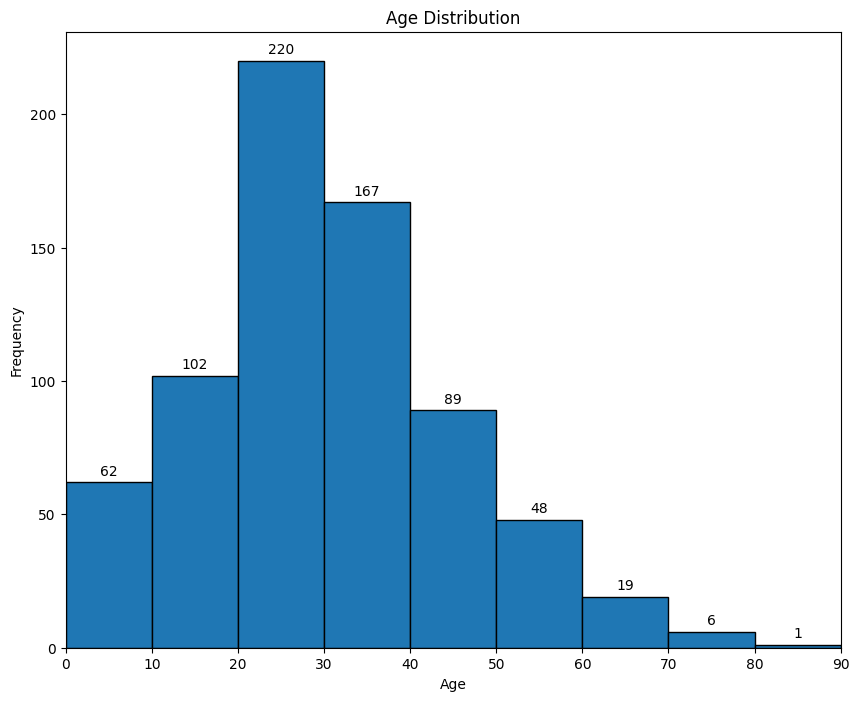

In [25]:
# age

fig, ax = plt.subplots(figsize=(10, 8))
bins = range(0, 100, 10)
counts, bin_edges, patches = ax.hist(df['Age'], label='Age', bins=bins, edgecolor='black', density=False)
ax.bar_label(patches, padding=3)
ax.set_title("Age Distribution")
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
ax.set_xticks(range(0, 100, 10))
ax.set_xlim(min(bins), max(bins))
plt.show()


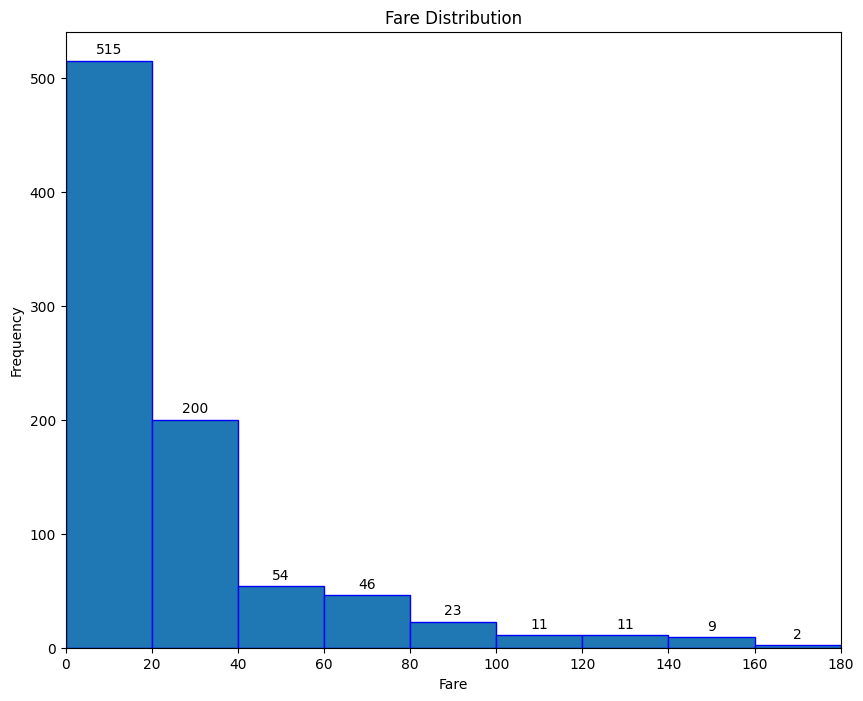

In [26]:
fig, ax = plt.subplots(figsize=(10, 8))
bins = range(0, 200, 20)
counts, bin_edges, patches = ax.hist(df['Fare'][df['Fare']<= 200], bins=bins, edgecolor='blue', density=False)
ax.set_title("Fare Distribution")
ax.set_xlabel("Fare")
ax.set_ylabel("Frequency")
ax.set_xticks(bins)
ax.set_xlim(min(bins), max(bins))
ax.bar_label(patches, padding=3)
ax.set_xscale('linear')
plt.show()

[  7   5  18  16  28 209 608]


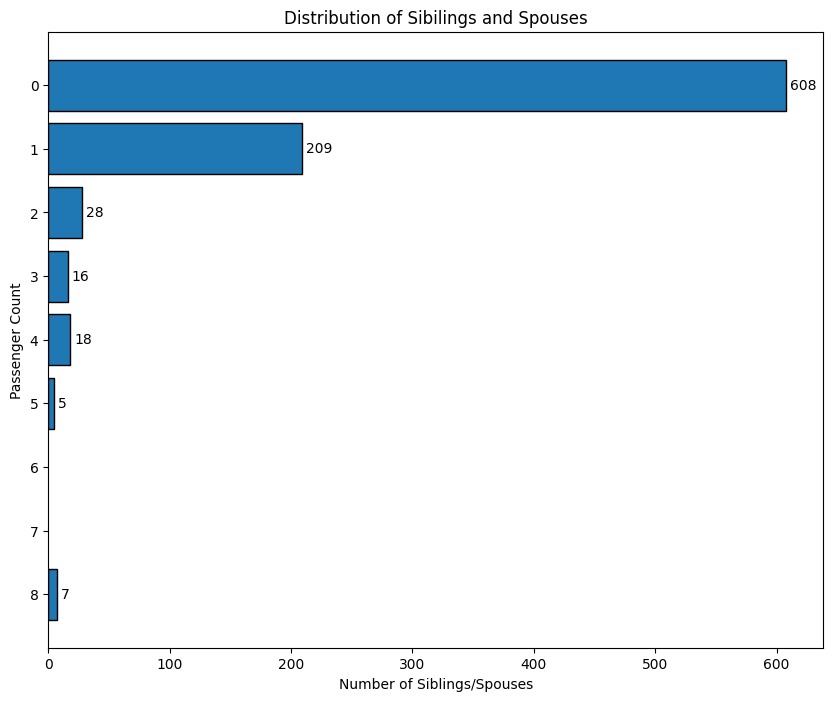

In [27]:
temp = df["SibSp"].value_counts().sort_index(ascending=False)
print(temp.values)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(temp.index, temp.values, edgecolor='black')
ax.invert_yaxis()
ax.set_yticks(range(0, 9, 1))
ax.bar_label(ax.containers[0], padding=3)
plt.xlabel("Number of Siblings/Spouses")
plt.ylabel("Passenger Count")
plt.title("Distribution of Sibilings and Spouses")
plt.show()

# There are outliers in the sibilings and spouses, better to ignore them

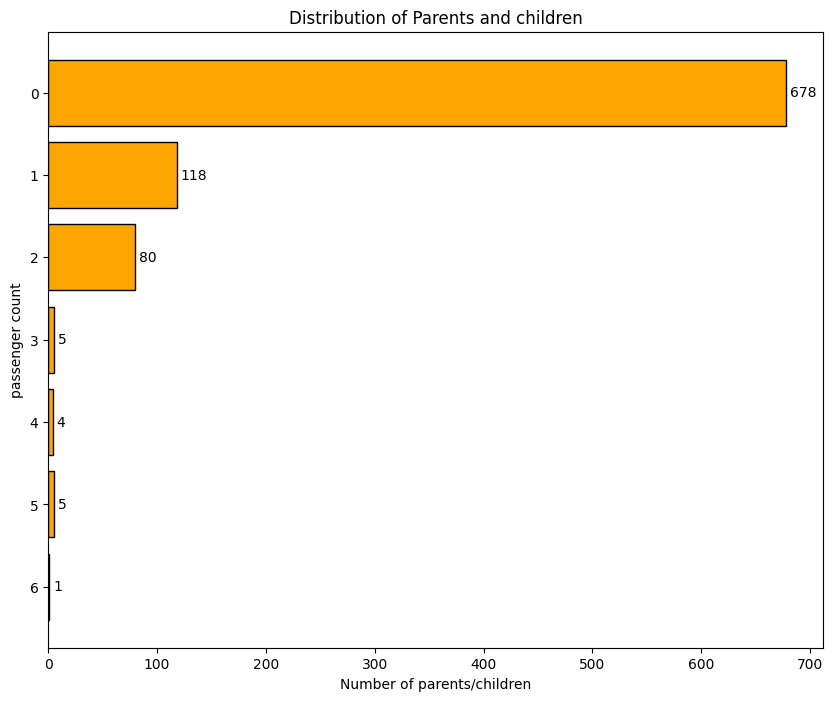

In [28]:
temp = df['Parch'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(temp.index, temp.values, color='orange', edgecolor='black')

ax.invert_yaxis()
ax.set_yticks(range(0, 7, 1))
ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Distribution of Parents and children")
ax.set_xlabel("Number of parents/children")
ax.set_ylabel("passenger count")
plt.show()


[[ 81 233]
 [468 109]]


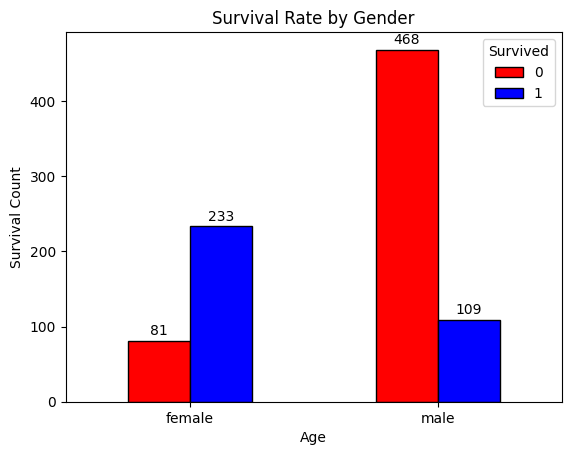

In [29]:
temp = pd.crosstab(df['Sex'], df['Survived'])
print(temp.values)
ax = temp.plot(kind='bar', color=['red', 'blue'], edgecolor='black')
# ax.invert_yaxis()
for container in ax.containers:
    ax.bar_label(container, padding=2)
ax.set_title("Survival Rate by Gender")
ax.set_xlabel("Age")
ax.tick_params(axis='x', rotation=0)
ax.set_ylabel("Survival Count")
plt.show()

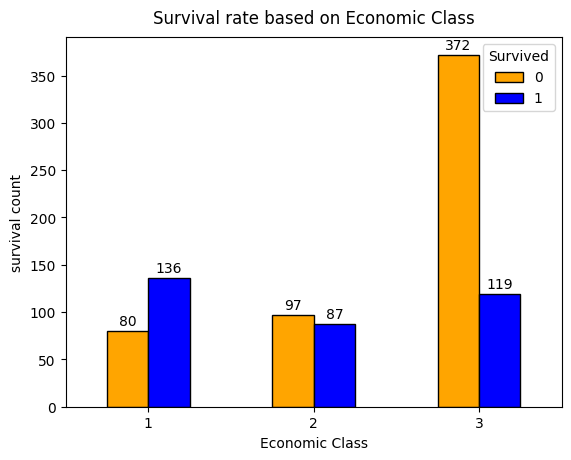

In [30]:
temp = pd.crosstab(df['Pclass'], df['Survived'])
ax = temp.plot(kind='bar', color=['orange', 'blue'], edgecolor='black')
ax.set_title("Survival rate based on Economic Class", loc='center', pad=10)
ax.set_xlabel("Economic Class")
ax.set_ylabel("survival count")

for container in ax.containers:
    ax.bar_label(container, padding=2)
ax.tick_params(axis='x', rotation=0)
plt.show()

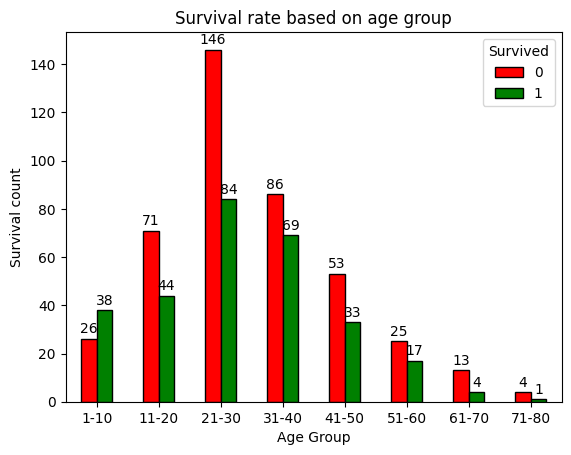

In [31]:

labels = [f"{i-9}-{i}" for i in range(10, 100, 10)]
df['AgeGroup'] = pd.cut(df['Age'], bins=range(0, 100, 10), labels=labels)
temp = pd.crosstab(df['AgeGroup'], df['Survived'])

ax = temp.plot(kind='bar', color=['red', 'green'], edgecolor='black')
ax.set_title("Survival rate based on age group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Survival count")
for container in ax.containers:
    ax.bar_label(container, padding=2)

ax.tick_params(axis='x', rotation=0)
plt.show()

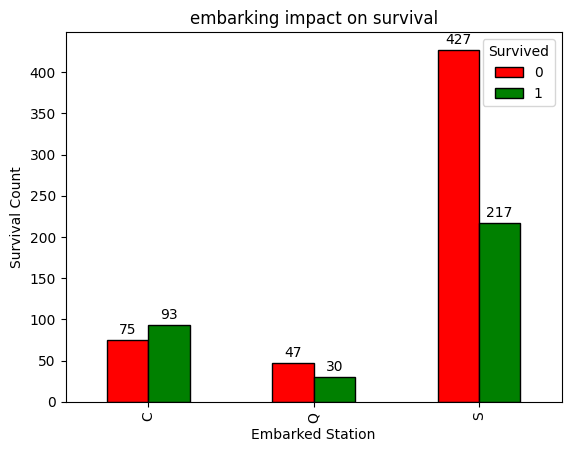

In [84]:
temp = pd.crosstab(df['Embarked'], df['Survived'])

ax = temp.plot(kind='bar', color=['red', 'green'], edgecolor='black')
for container in ax.containers:
    ax.bar_label(container, padding=2)
# ax.bar_label(ax.containers)
ax.set_title("embarking impact on survival")
ax.set_xlabel("Embarked Station")
ax.set_ylabel("Survival Count")
plt.show()

### Feature Relationships

* Age vs Fare
* Pclass vs Fare
* Family size vs Survival

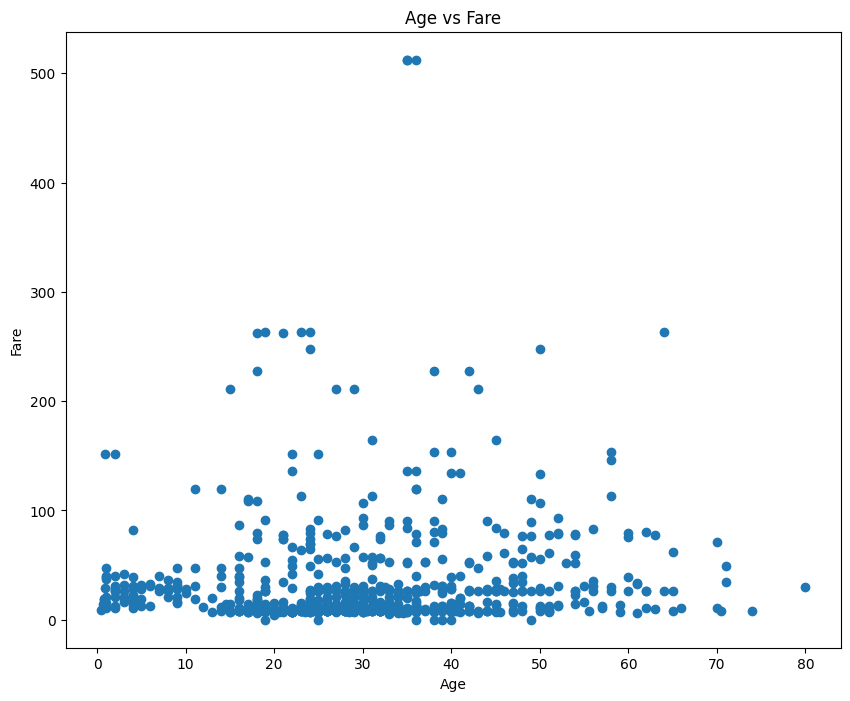

In [32]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df['Age'], df['Fare'])
ax.set_title("Age vs Fare")
ax.set_xlabel("Age")
ax.set_ylabel("Fare")
plt.show()

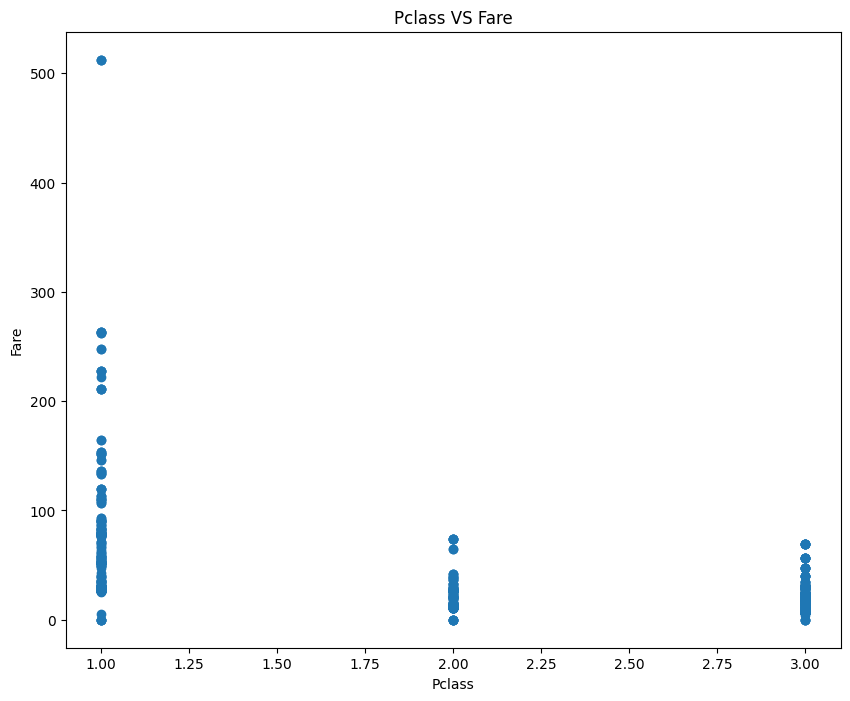

In [33]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df['Pclass'], df['Fare'])
ax.set_title("Pclass VS Fare")
ax.set_xlabel("Pclass")
ax.set_ylabel("Fare")
plt.show()

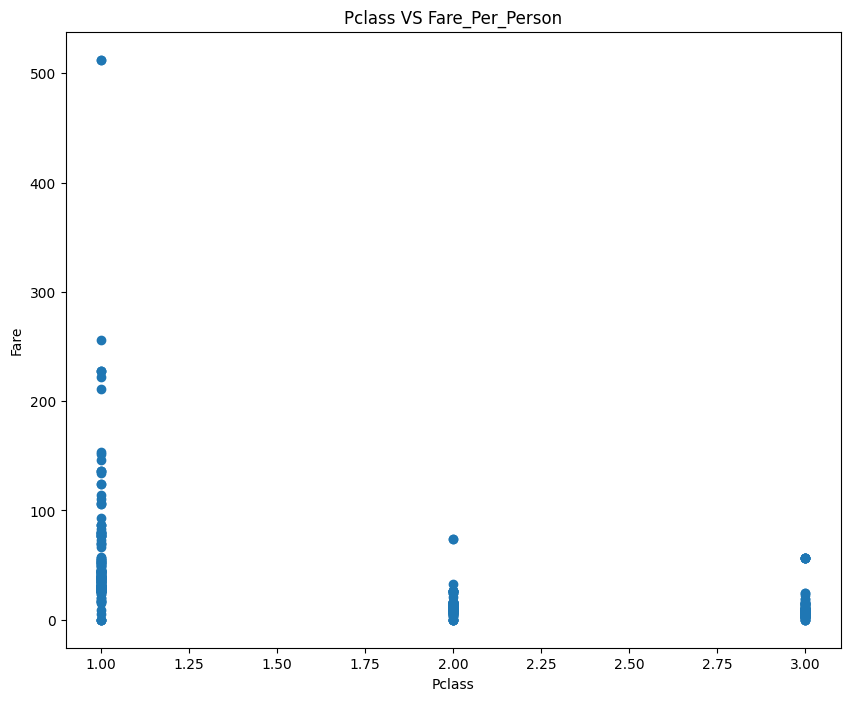

In [59]:
df['Fare_Per_Person'] = df['Fare']/(df['SibSp'] + df['Parch']+1)

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(df['Pclass'], df['Fare_Per_Person'])
ax.set_title("Pclass VS Fare_Per_Person")
ax.set_xlabel("Pclass")
ax.set_ylabel("Fare")
plt.show()

In [60]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup',
       'Fare_Per_Person'],
      dtype='object')

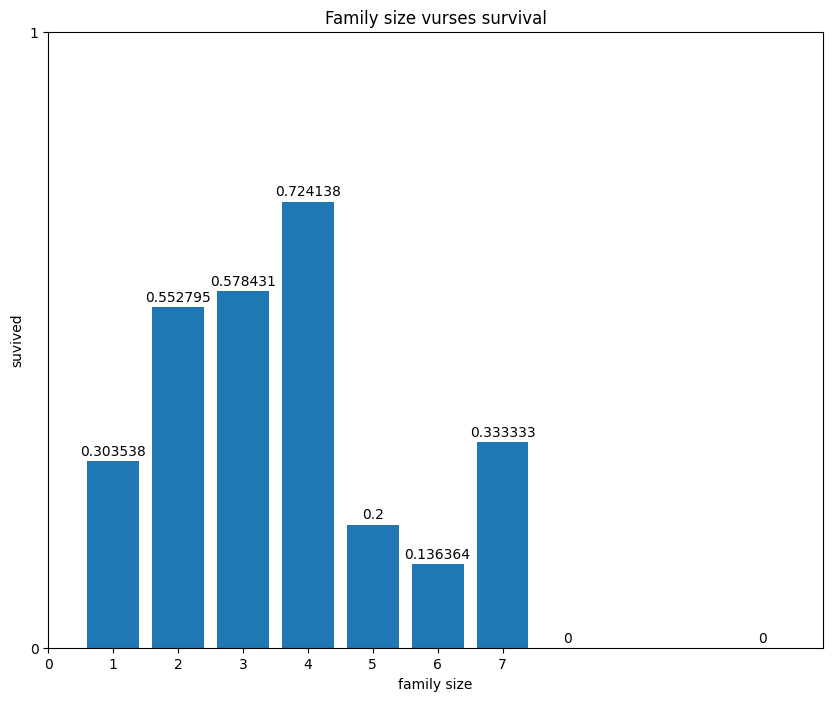

In [78]:
# family size vs survaval
df['family_size'] = df['SibSp'] + df['Parch'] + 1

temp = df.groupby('family_size')['Survived'].mean()
fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.bar(temp.index, temp.values)
ax.set_title("Family size vurses survival")
ax.set_yticks([0, 1])
ax.set_xticks(range(0, 8, 1))
ax.bar_label(bars, padding =2)
ax.set_xlabel("family size")
ax.set_ylabel("suvived")
plt.show()

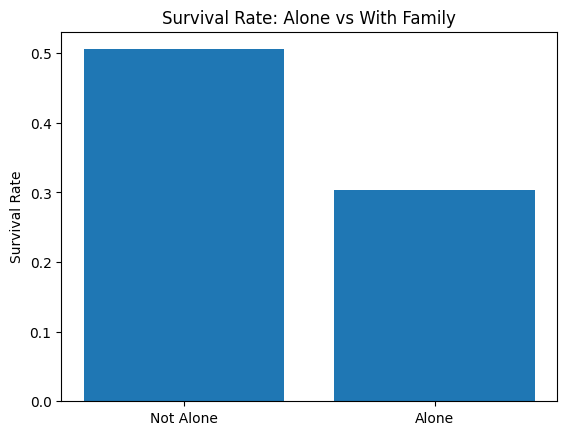

In [86]:
df['IsAlone'] = (df['family_size'] == 1).astype(int)

alone_survival = df.groupby('IsAlone')['Survived'].mean()

plt.bar(['Not Alone','Alone'], alone_survival.values)

plt.title("Survival Rate: Alone vs With Family")
plt.ylabel("Survival Rate")

plt.show()

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/var/folders/cm/xbcw7tbj7ks0tkxmz2yy2pch0000gn/T/ipykernel_4916/249905567.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')


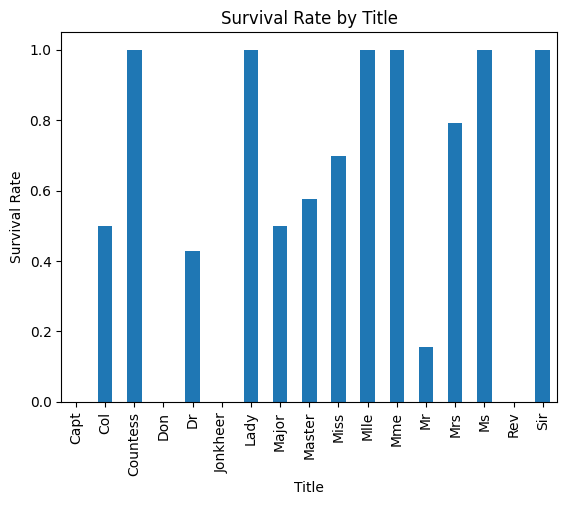

In [87]:
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.')

title_survival = df.groupby('Title')['Survived'].mean()

title_survival.plot(kind='bar')

plt.title("Survival Rate by Title")
plt.ylabel("Survival Rate")

plt.show()

In [88]:
df['Deck'] = df['Cabin'].str[0]
df['Deck']

0      NaN
1        C
2      NaN
3        C
4      NaN
      ... 
886    NaN
887      B
888    NaN
889      C
890    NaN
Name: Deck, Length: 891, dtype: object